# Predicting Airline Passenger Satisfaction Using Machine Learning

#### -> The goal is to develop a machine learning model that predicts whether a passenger is Satisfied or Dissatisfied.

## 1. Importing Required Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings  # For avoid deprecation
warnings.filterwarnings('ignore') 

## 2. Loading the Dataset

In [6]:
# retrive data from xlxs file 

data=pd.read_csv('Data.csv')
df=pd.DataFrame(data)
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## 3. Data Exploration

In [8]:
# to check shape of dataframe
df.shape

(129880, 24)

In [9]:
# to check information details of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  object 
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

In [10]:
# to check missing values
df.isnull().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

In [11]:
#To fill the missing values
df['Arrival Delay'].fillna(df['Arrival Delay'].median(), inplace=True)

In [12]:
df.isnull().sum()

ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                

In [13]:
# to check duplicates
df.duplicated().sum()

0

In [15]:
# Summarize numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,129880.0,64940.500000,37493.270818,1.0,32470.75,64940.5,97410.25,129880.0
Age,129880.0,39.427957,15.119360,7.0,27.00,40.0,51.00,85.0
Departure Delay,129880.0,14.713713,38.071126,0.0,0.00,0.0,12.00,1592.0
Arrival Delay,129880.0,15.045465,38.416353,0.0,0.00,0.0,13.00,1584.0
Departure and Arrival Time Convenience,129880.0,3.057599,1.526741,0.0,2.00,3.0,4.00,5.0
Ease of Online Booking,129880.0,2.756876,1.401740,0.0,2.00,3.0,4.00,5.0
Check-in Service,129880.0,3.306267,1.266185,0.0,3.00,3.0,4.00,5.0
Online Boarding,129880.0,3.252633,1.350719,0.0,2.00,3.0,4.00,5.0
Gate Location,129880.0,2.976925,1.278520,0.0,2.00,3.0,4.00,5.0
On-board Service,129880.0,3.383023,1.287099,0.0,2.00,4.0,4.00,5.0


In [16]:
# Summarize categorical features
df.describe(include=['object'])

,Gender,Customer Type,Type of Travel,Class,Flight Distance,Satisfaction
count,129880,129880,129880,129880,129880,129880
unique,2,2,2,3,6848,2
top,Female,Returning,Business,Business,337,Neutral or Dissatisfied
freq,65899,106100,89693,62160,840,73452


## 4. Exploratory Data Analysis (EDA)

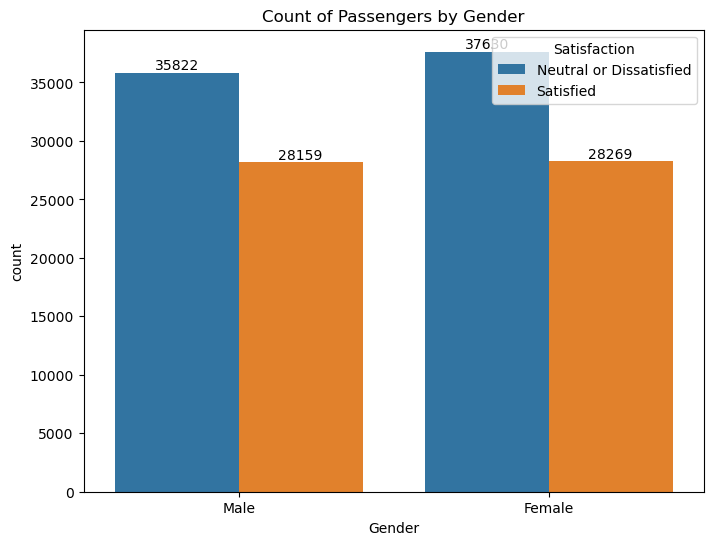

In [18]:
# count of Passengers who satisfied or Dissatisfied
plt.figure(figsize=(8, 6))
ax=sns.countplot(data=df, x='Gender', hue='Satisfaction')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Count of Passengers by Gender")
plt.show()

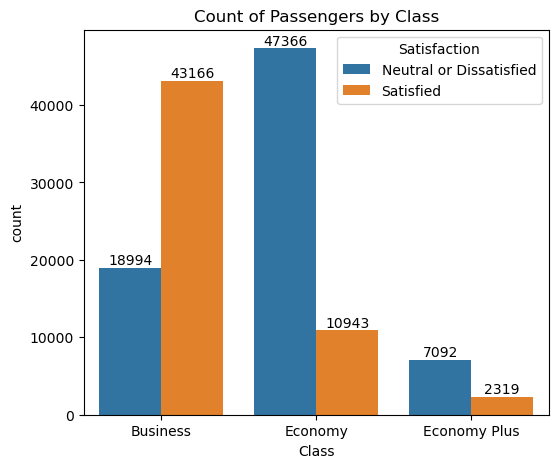

In [19]:
# Count of Passengers by Class
plt.figure(figsize=(6, 5))
ax=sns.countplot(data=df, x='Class', hue='Satisfaction')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Count of Passengers by Class")
plt.show()

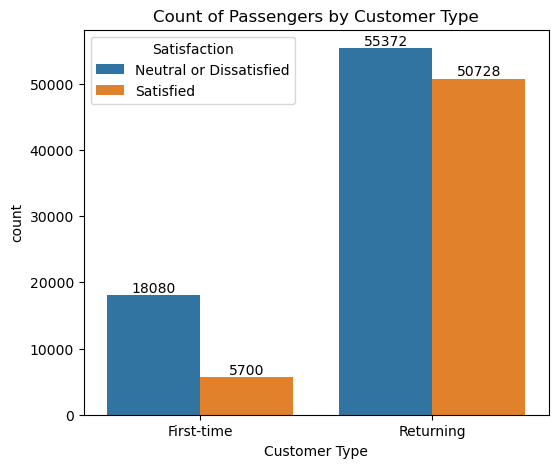

In [20]:
# Count of Passengers by Customer Type
plt.figure(figsize=(6, 5))
ax=sns.countplot(data=df, x='Customer Type', hue='Satisfaction')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Count of Passengers by Customer Type")
plt.show()

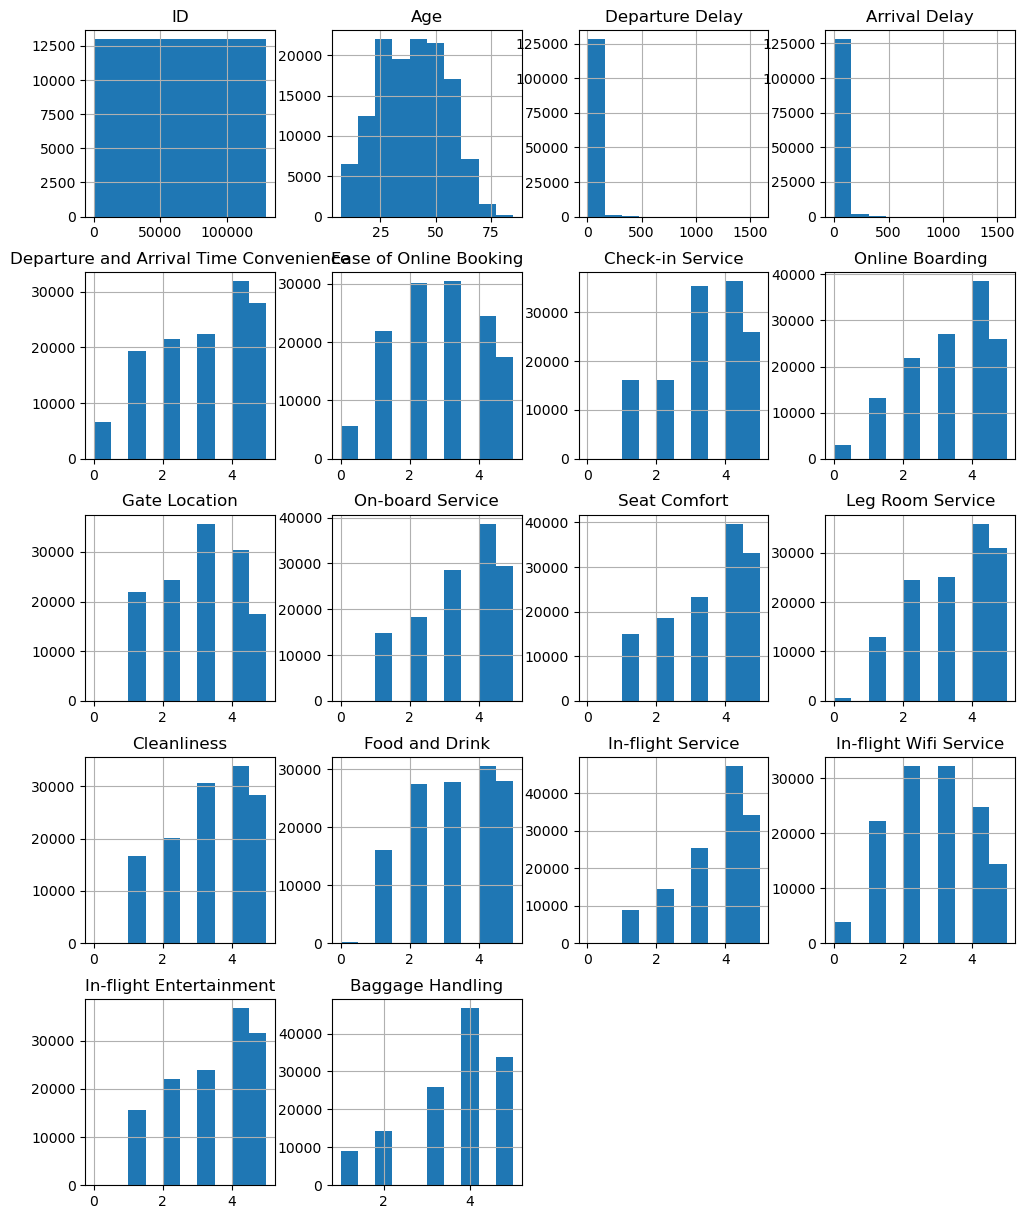

In [21]:
# Plot histogram grid
# Displays continuous numerical data by dividing it into bins
df.hist(figsize=(12,15))
plt.show()

In [22]:
# to check the shape of dataset
df.shape

(129880, 24)

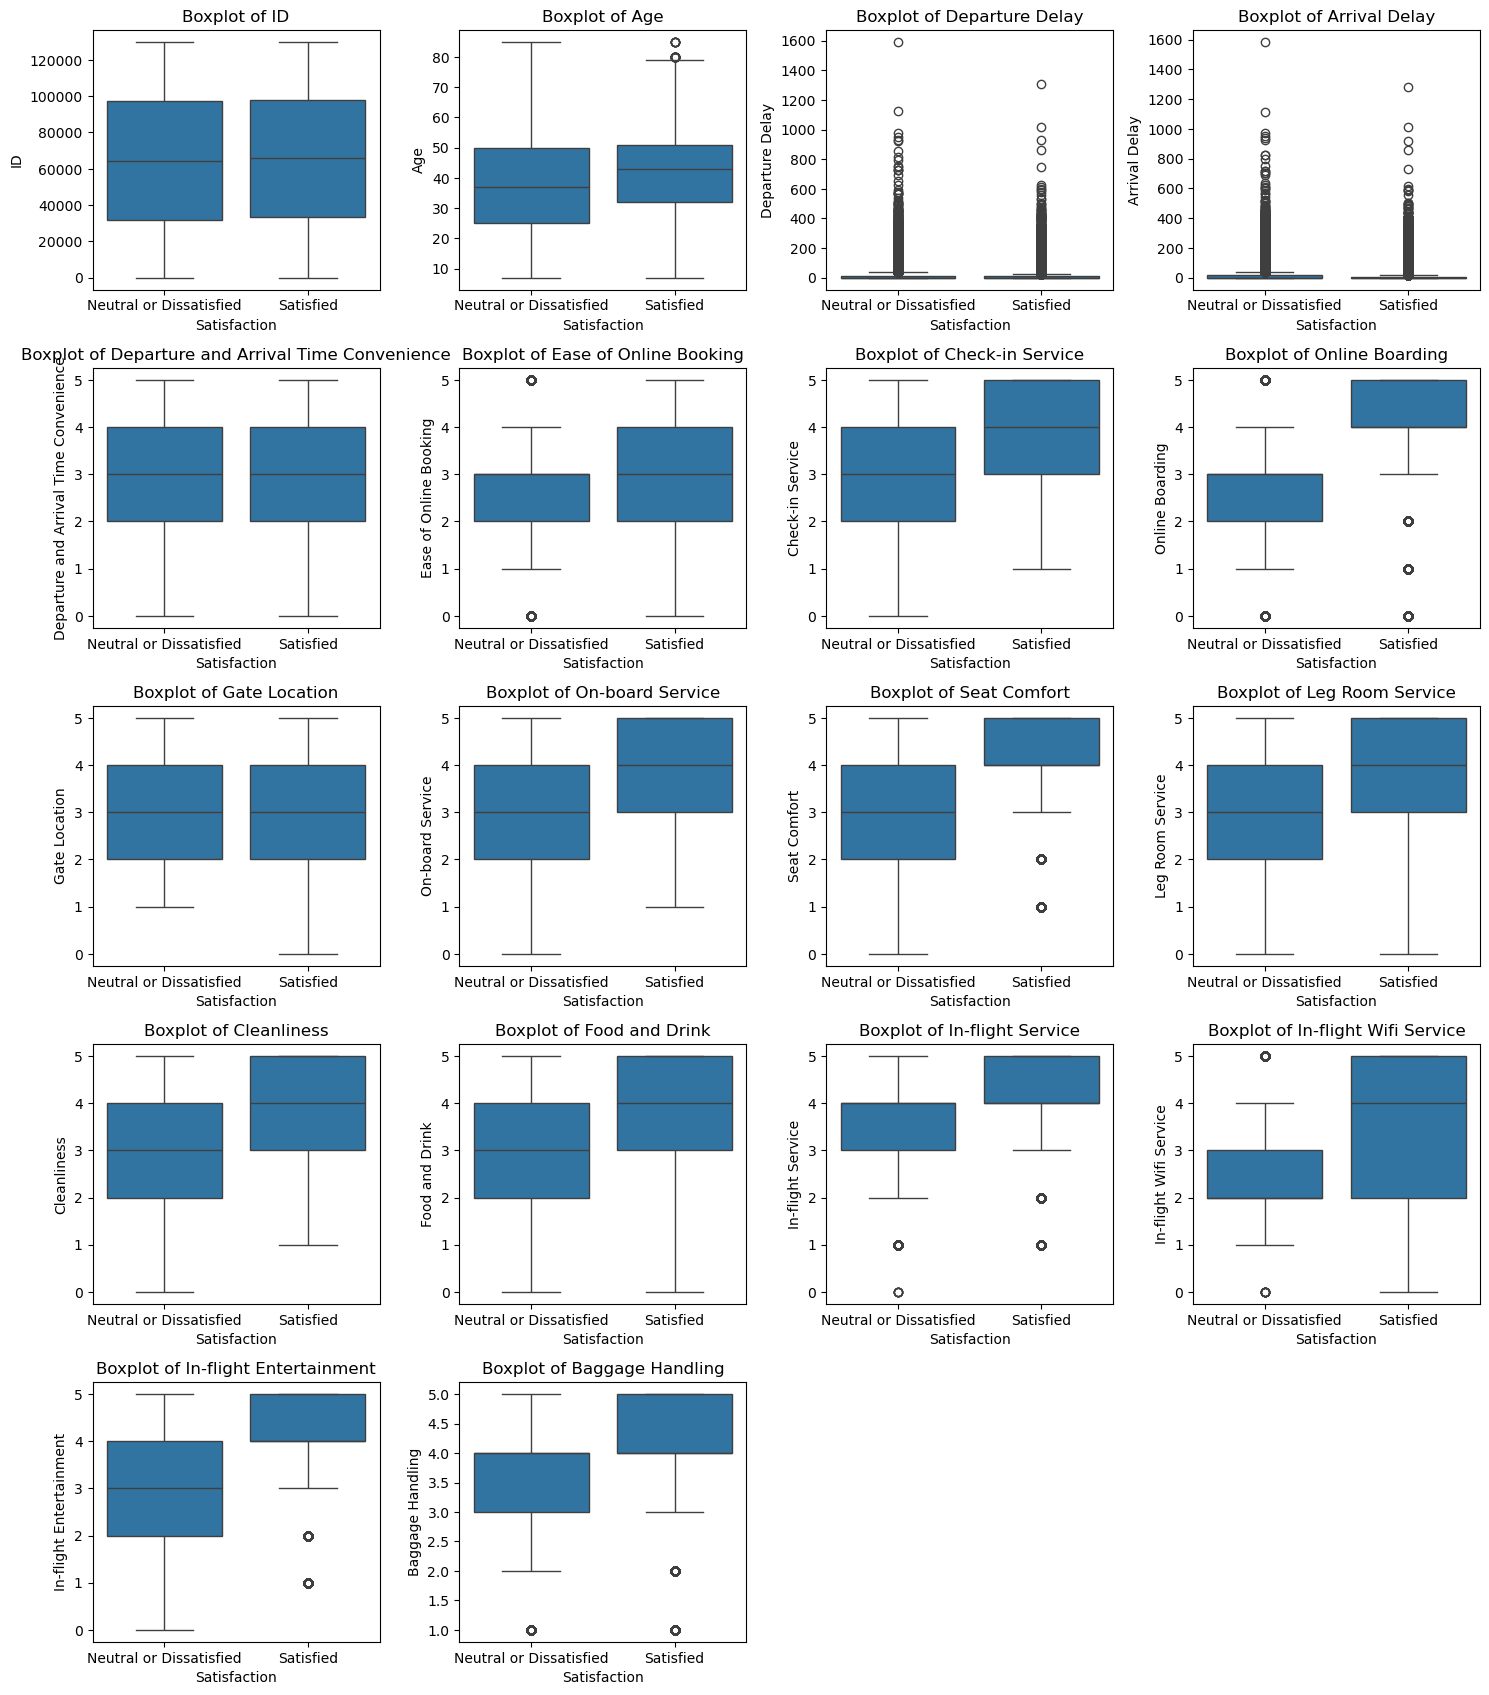

In [23]:
# to check the outliers using boxplot
x=df.select_dtypes(exclude=['object']).columns
plt.figure(figsize=(15, 20))
for i, feature in enumerate(x):
    plt.subplot(6, 4, i+1)
    sns.boxplot(x='Satisfaction', y=feature, data=df)
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

In [25]:
# remove the outliers
outlier=['Departure Delay', 'Arrival Delay']
for i in outlier:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
        
        # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
        
        # Remove outliers
    df1 = df[(df[i] >= lower_bound) & (df[i] <= upper_bound)]
    
df1.shape

(112388, 24)

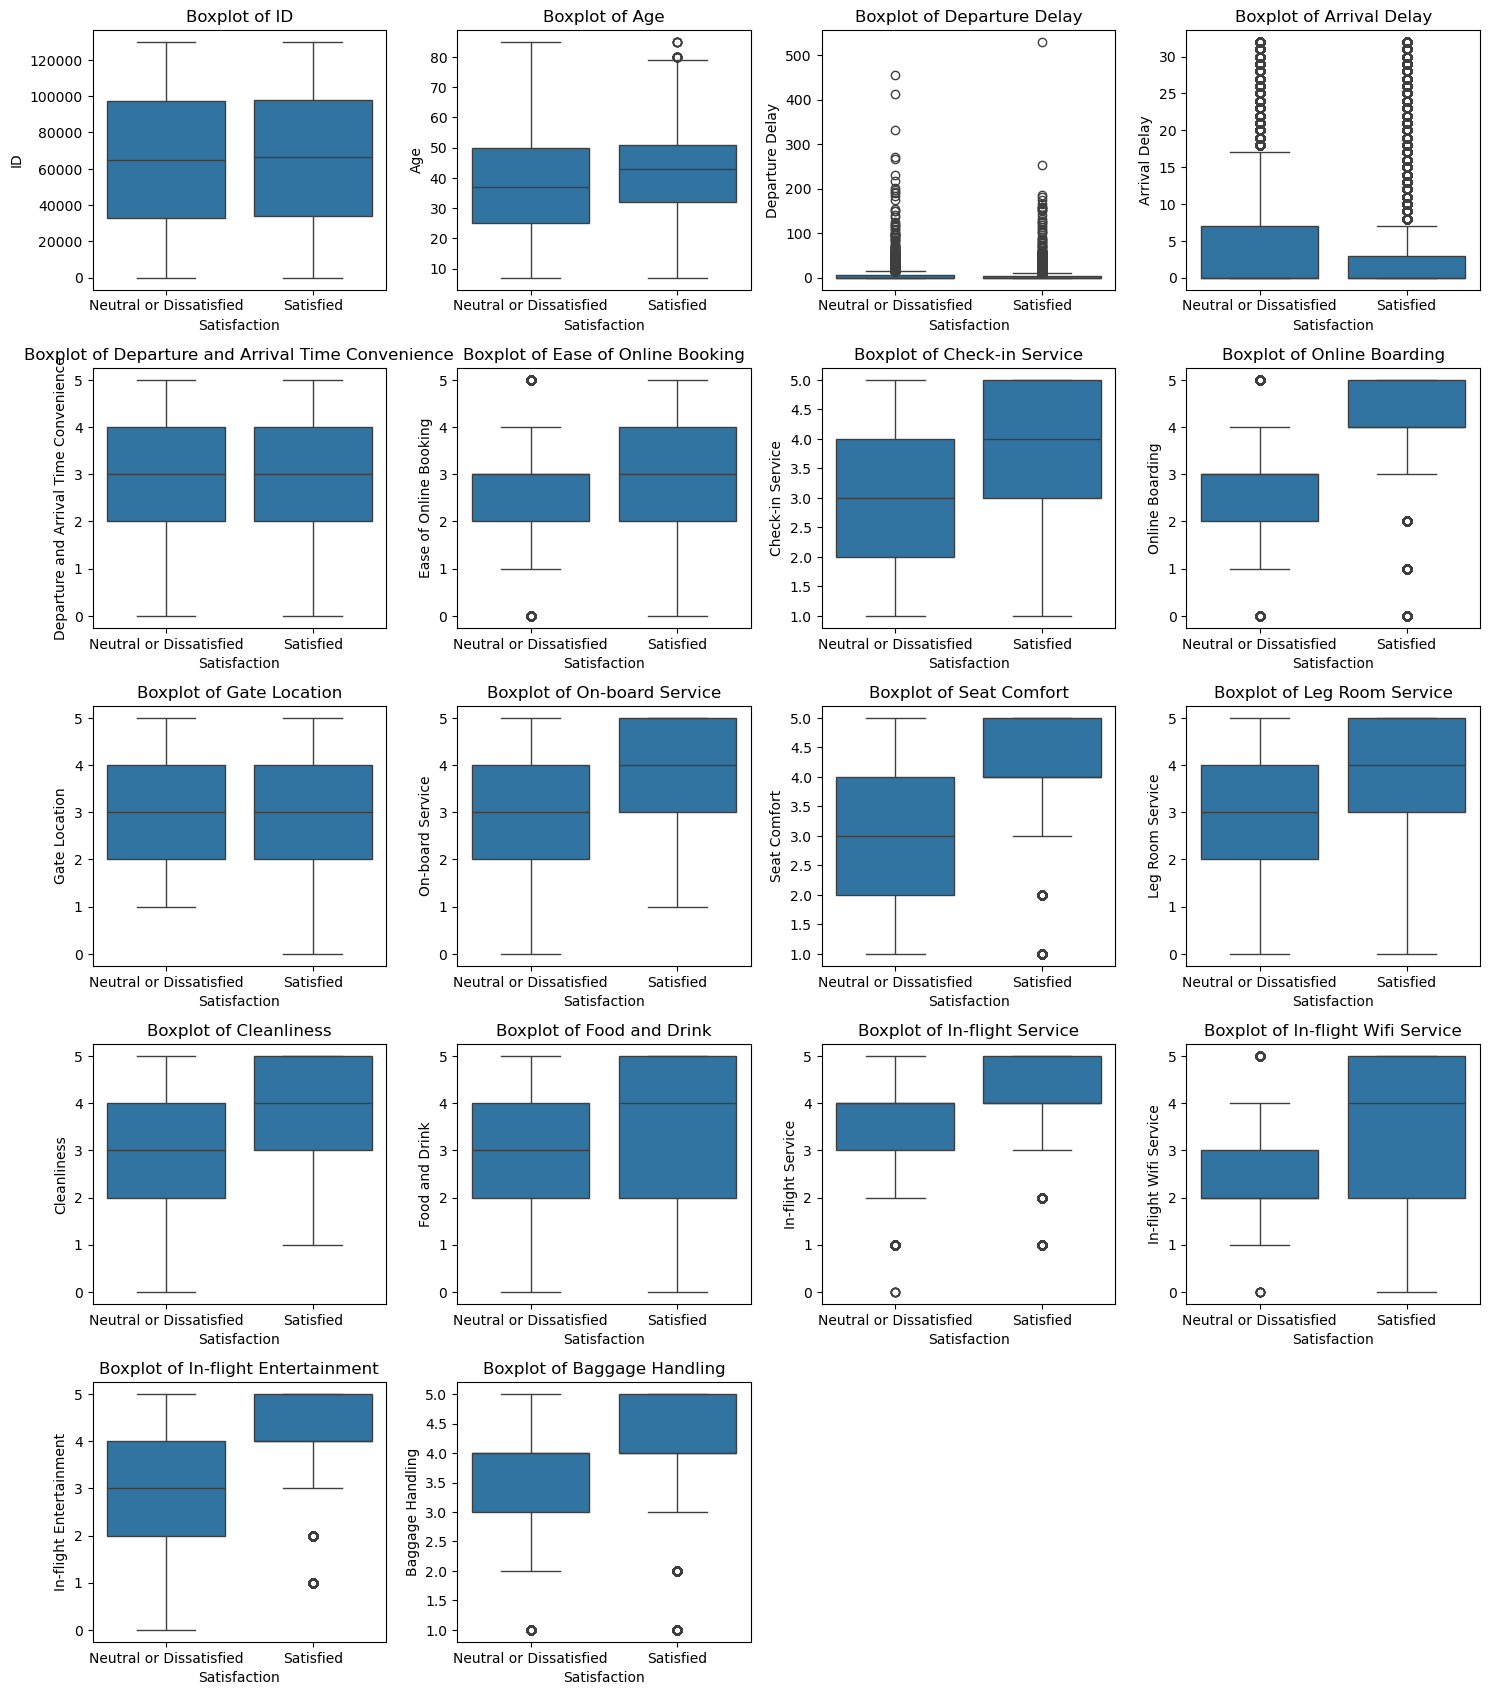

In [26]:
# After removed the outliers of boxplot
plt.figure(figsize=(15, 20))
for i, feature in enumerate(x):
    plt.subplot(6, 4, i+1)
    sns.boxplot(x='Satisfaction', y=feature, data=df1)
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

In [28]:
df.describe(include=['object'])

,Gender,Customer Type,Type of Travel,Class,Flight Distance,Satisfaction
count,129880,129880,129880,129880,129880,129880
unique,2,2,2,3,6848,2
top,Female,Returning,Business,Business,337,Neutral or Dissatisfied
freq,65899,106100,89693,62160,840,73452


In [29]:
# convert a object type to int type using label encoder
from sklearn.preprocessing import LabelEncoder
categorical_cols=['Satisfaction', 'Gender', 'Class', 'Type of Travel', 'Customer Type', 'Flight Distance']
label_encoders = {}
for col in categorical_cols:
    df1[col] = df1[col].astype(str)
    label_encoders[col] = LabelEncoder()  # Create a LabelEncoder for each column
    df1[col] = label_encoders[col].fit_transform(df1[col])  # Transform the column

In [32]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112388 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      112388 non-null  int64  
 1   Gender                                  112388 non-null  int32  
 2   Age                                     112388 non-null  int64  
 3   Customer Type                           112388 non-null  int32  
 4   Type of Travel                          112388 non-null  int32  
 5   Class                                   112388 non-null  int32  
 6   Flight Distance                         112388 non-null  int32  
 7   Departure Delay                         112388 non-null  int64  
 8   Arrival Delay                           112388 non-null  float64
 9   Departure and Arrival Time Convenience  112388 non-null  int64  
 10  Ease of Online Booking                  112388 no

In [33]:
df1['Arrival Delay'] = df1['Arrival Delay'].astype(int)

In [36]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112388 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   ID                                      112388 non-null  int64
 1   Gender                                  112388 non-null  int32
 2   Age                                     112388 non-null  int64
 3   Customer Type                           112388 non-null  int32
 4   Type of Travel                          112388 non-null  int32
 5   Class                                   112388 non-null  int32
 6   Flight Distance                         112388 non-null  int32
 7   Departure Delay                         112388 non-null  int64
 8   Arrival Delay                           112388 non-null  int32
 9   Departure and Arrival Time Convenience  112388 non-null  int64
 10  Ease of Online Booking                  112388 non-null  int64
 11  Check

In [40]:
# Correlation analysis is a statistical technique for determining the strength of a link between two variables
corr=df1.corr()
corr

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
ID,1.000000,-0.000240,0.019969,-0.001404,0.001013,-0.105887,-0.017548,0.062490,0.017655,-0.002652,...,0.055309,0.051881,0.043172,0.022860,-0.003607,0.077688,-0.024732,-0.002194,0.074265,0.010773
Gender,-0.000240,1.000000,0.010575,0.032256,0.011769,-0.009629,-0.002015,0.005962,0.001675,0.008735,...,0.005162,-0.031113,0.030883,0.004108,0.002681,0.038526,0.005064,0.004076,0.037853,0.010623
Age,0.019969,0.010575,1.000000,0.285057,-0.044740,-0.117201,-0.026888,-0.003539,-0.009682,0.037597,...,0.058593,0.161365,0.042914,0.051990,0.019448,-0.053665,0.015367,0.074609,-0.049371,0.132133
Customer Type,-0.001404,0.032256,0.285057,1.000000,0.307949,-0.039878,-0.047600,-0.001675,-0.005766,0.205836,...,0.053541,0.160926,0.047940,0.084936,0.057926,-0.025256,0.006114,0.109847,-0.027949,0.189703
Type of Travel,0.001013,0.011769,-0.044740,0.307949,1.000000,0.492764,0.063708,-0.000600,-0.005949,0.256197,...,-0.068305,-0.133372,-0.147181,-0.088992,-0.066962,-0.031069,-0.103792,-0.164394,-0.041808,-0.453320
Class,-0.105887,-0.009629,-0.117201,-0.039878,0.492764,1.000000,0.097486,-0.000081,0.015682,0.088936,...,-0.217730,-0.215823,-0.202897,-0.130632,-0.075540,-0.163271,-0.020176,-0.186120,-0.170749,-0.447000
Flight Distance,-0.017548,-0.002015,-0.026888,-0.047600,0.063708,0.097486,1.000000,0.006328,0.015131,0.005946,...,-0.026220,-0.040421,-0.027525,-0.027023,-0.021250,-0.009799,-0.003666,-0.036434,0.000060,-0.076372
Departure Delay,0.062490,0.005962,-0.003539,-0.001675,-0.000600,-0.000081,0.006328,1.000000,0.605551,0.002318,...,-0.016529,-0.012933,-0.008273,-0.011217,-0.009729,-0.010750,-0.017378,-0.017257,-0.008852,-0.047478
Arrival Delay,0.017655,0.001675,-0.009682,-0.005766,-0.005949,0.015682,0.015131,0.605551,1.000000,-0.001374,...,-0.037649,-0.025280,-0.024736,-0.026514,-0.021693,-0.031157,-0.027490,-0.034946,-0.029985,-0.086705
Departure and Arrival Time Convenience,-0.002652,0.008735,0.037597,0.205836,0.256197,0.088936,0.005946,0.002318,-0.001374,1.000000,...,0.067505,0.008039,0.007602,0.010020,-0.001196,0.071827,0.350522,-0.012145,0.069190,-0.053721


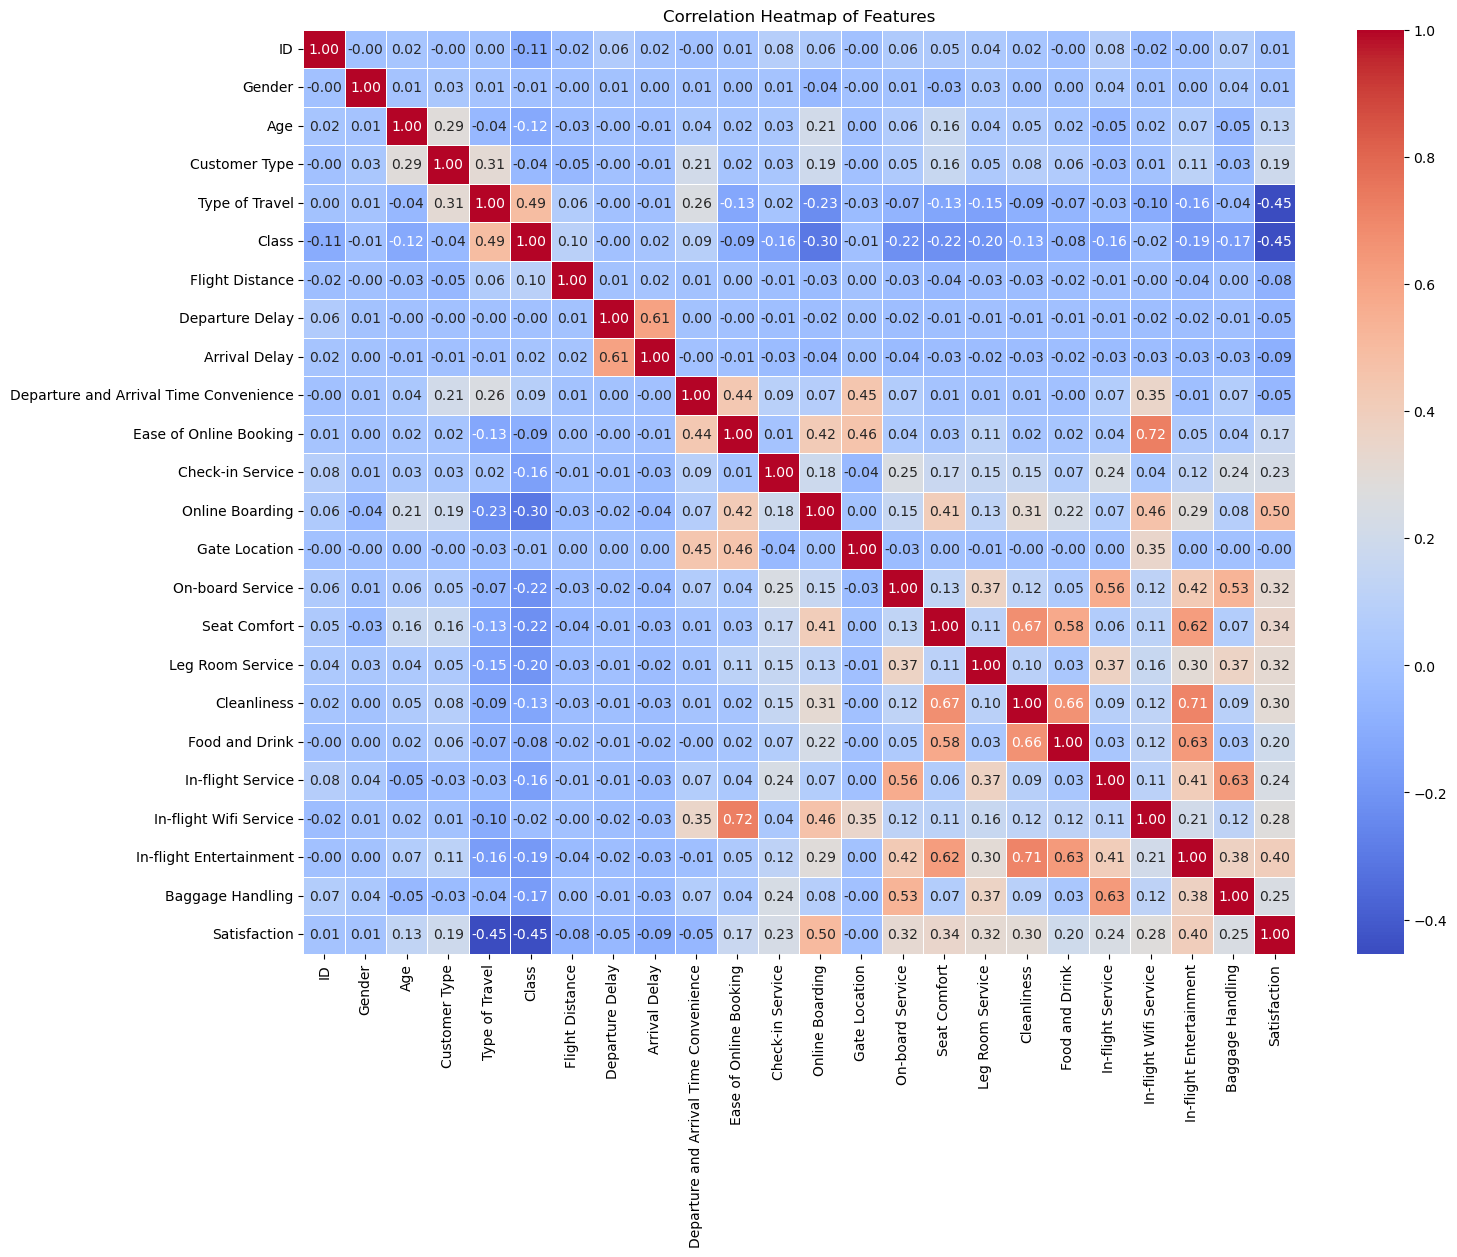

In [42]:
# heat map visualization for correlation
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

In [48]:
# define features and target varibles
X=df1.drop(columns=['Satisfaction']) # Features Variable(Input Variable)
y=df1['Satisfaction']  # Target Variable

In [49]:
X.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
0,1,1,48,0,0,0,3630,2,5,3,...,3,3,5,2,5,5,5,3,5,5
2,3,1,41,1,0,0,3664,0,0,4,...,4,3,5,3,5,5,3,4,3,3
3,4,1,50,1,0,0,929,0,0,2,...,2,5,5,5,4,4,5,2,5,5
4,5,0,49,1,0,0,2646,0,1,3,...,3,3,4,4,5,4,3,3,3,3
5,6,1,43,1,0,0,2995,0,0,4,...,4,4,4,4,3,3,4,4,4,4


## 5. Handle Imbalance using SMOTE

In [51]:
#SMOTE (synthetic minority oversampling technique) is one of the most commonly used oversampling methods to solve the imbalance problem.

from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [52]:
X_resampled.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
0,1,1,48,0,0,0,3630,2,5,3,...,3,3,5,2,5,5,5,3,5,5
1,3,1,41,1,0,0,3664,0,0,4,...,4,3,5,3,5,5,3,4,3,3
2,4,1,50,1,0,0,929,0,0,2,...,2,5,5,5,4,4,5,2,5,5
3,5,0,49,1,0,0,2646,0,1,3,...,3,3,4,4,5,4,3,3,3,3
4,6,1,43,1,0,0,2995,0,0,4,...,4,4,4,4,3,3,4,4,4,4


## 6. Train-Test Split

In [55]:
# Model Training and Testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X_resampled,y_resampled,test_size=0.3, random_state=42)

In [57]:
X_test.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
57576,67226,0,27,1,1,1,3739,5,0,5,...,1,4,1,1,5,5,5,1,5,1
55404,64743,1,22,0,0,0,923,0,0,4,...,2,5,4,5,4,4,5,0,4,4
65514,76167,1,17,1,1,1,3498,3,0,4,...,3,4,2,3,2,2,4,2,2,3
80076,92515,1,55,1,1,1,944,0,0,5,...,4,5,4,2,3,3,4,3,3,4
102353,118747,0,58,1,1,1,3434,0,0,4,...,4,5,5,2,3,5,5,2,5,4


## 7. Model Building

In [60]:
# import algorithm libraries

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [77]:
#Logistic Regression

model_lr = LogisticRegression(max_iter=10000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

#Decision Tree

model_dt= DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

#Random Forest

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

#XGBoost classifier

model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb=model_xgb.predict(X_test)

# #Support Vector Machine (SVM)

# model_svm = SVC(random_state=42)
# model_svm.fit(X_train, y_train)
# y_pred_svm = model_svm.predict(X_test)

#Naive Bayes

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

#k-Nearest Neighbors (kNN)

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

## 8. Model Evaluation

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

res={}
def evaluate_model(y_test, y_pred):
   return {
        "Accuracy": round(accuracy_score(y_test, y_pred)*100,2),
        "Precision": round(precision_score(y_test, y_pred), 2),
        "Recall": round(recall_score(y_test, y_pred), 2),
        "F1-Score": round(f1_score(y_test, y_pred), 2),
        "ROC AUC": round(roc_auc_score(y_test, y_pred),2)
    }

res['Logistic Regression']= evaluate_model(y_test, y_pred_lr)

res['Decision Tree']= evaluate_model(y_test, y_pred_dt)

res['Random Forest']= evaluate_model(y_test, y_pred_rf)

res['XGBoost']= evaluate_model(y_test, y_pred_xgb)

# res['Support Vector Machine']= evaluate_model(y_test, y_pred_svm)

res['Naive Bayes']= evaluate_model(y_test, y_pred_nb)

res['K-Nearest Neighbors']= evaluate_model(y_test, y_pred_knn)


res_df=pd.DataFrame(res)
res_df

,Logistic Regression,Decision Tree,Random Forest,XGBoost,Naive Bayes,K-Nearest Neighbors
Accuracy,86.09,93.48,95.57,95.68,77.67,67.23
Precision,0.86,0.93,0.97,0.97,0.75,0.66
Recall,0.86,0.94,0.94,0.95,0.82,0.69
F1-Score,0.86,0.93,0.95,0.96,0.79,0.68
ROC AUC,0.86,0.93,0.96,0.96,0.78,0.67


## 9. Visualization of Evaluation Metrics 

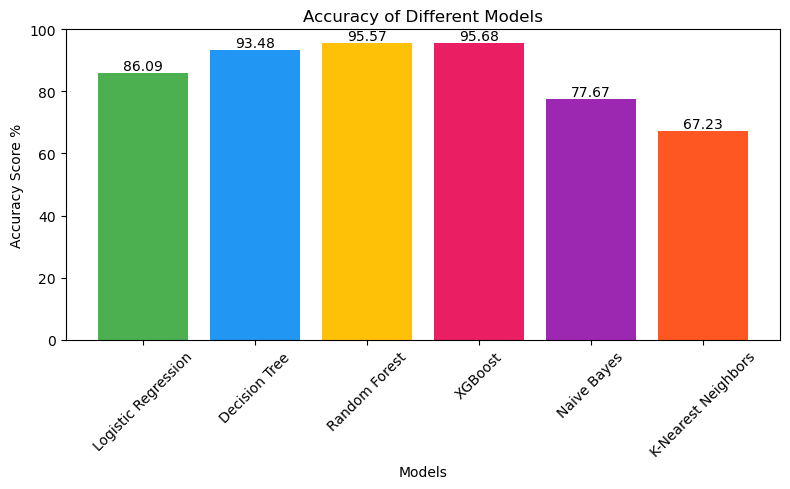

In [82]:
accuracies = res_df.iloc[0]

plt.figure(figsize=(8, 5))
plt.bar(res_df.columns,accuracies , color = ['#4CAF50', '#2196F3', '#FFC107','#E91E63','#9C27B0', '#FF5722', '#3F51B5'] )

plt.title('Accuracy of Different Models')
plt.xlabel('Models')
plt.ylabel('Accuracy Score %')
plt.ylim(0, 100)
plt.xticks(rotation=45)

for i, val in enumerate(accuracies):
    plt.text(i, val,f"{val}",ha='center', va='bottom')
    
plt.tight_layout()
plt.show()


## 10. Confusion Matrix

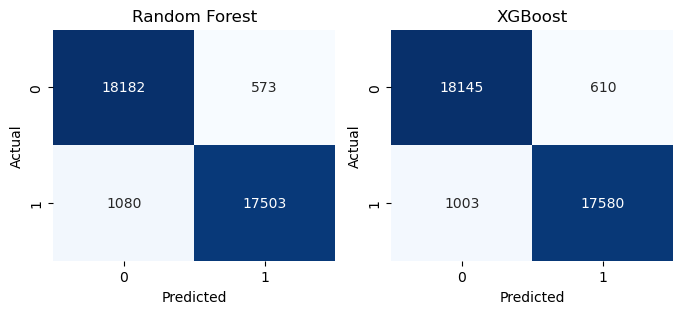

<Figure size 400x300 with 0 Axes>

<Figure size 400x300 with 0 Axes>

In [85]:
from sklearn.metrics import confusion_matrix


# Create a function to plot confusion matrix
def plot_confusion_matrix(ax, y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d',cmap='Blues', cbar=False,ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
# Plotting
plot_confusion_matrix(axes[0],y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(axes[1],y_test, y_pred_xgb, "XGBoost")

plt.tight_layout()
plt.show()

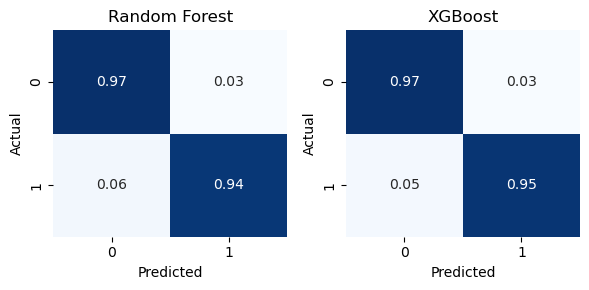

In [87]:


# Custom plot function with axes
def plot_confusion_matrix(ax, y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred, normalize='true')  # normalize to show percentages
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Create 1 row, 2 columns of plots
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Plot on subplots
plot_confusion_matrix(axes[0], y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(axes[1], y_test, y_pred_xgb, "XGBoost")

# Adjust layout
plt.tight_layout()
plt.show()


## 11. Predicting

In [138]:
ID=int(input("Enter the ID                          : "))
Gender=int(input("Enter the Gender                      : "))
Age=int(input("Enter the Age                         : "))
Customer_Type=int(input("Enter the Customer_Type               : "))
Type_of_Travel=int(input("Enter the Type_of_Travel              : "))
Class=int(input("Enter the Class                       : "))
Flight_Distance=int(input("Enter the Flight_Distance             : "))
Departure_Delay=int(input("Enter the Departure_Delay             : "))
Arrival_Delay=int(input("Enter the Arrival_Delay               : "))
DA_Time_Convenience=float(input("Enter the DA_Time_Convenience       : "))
Online_Booking=int(input("Enter the Online_Booking              : "))
CheckIn_Service=int(input("Enter the CheckIn_Service             : "))
Online_Boarding=int(input("Enter the Online_Boarding             : "))
Gate_Location=int(input("Enter the Gate_Location               : "))
OnBoard_Service=int(input("Enter the OnBoard_Service             : "))
Seat_Comfort=int(input("Enter the Seat_Comfort                : "))
LegRoom_Service=int(input("Enter the LegRoom_Service             : "))
Cleanliness=int(input("Enter the Cleanliness                 : "))
Food_Drink=int(input("Enter the Food_Drink                  : "))
InFlight_Service=int(input("Enter the InFlight_Service            : "))
In_flight_Wifi=int(input("Enter the In_flight_Wifi              : "))
InFlight_Entertainment=int(input("Enter the InFlight_Entertainment      : "))
Baggage_Handling=int(input("Enter the Baggage_Handling            : "))

pre=np.array([ID, Gender, Age, Customer_Type, Type_of_Travel, Class, Flight_Distance, Departure_Delay, Arrival_Delay, DA_Time_Convenience, Online_Booking, CheckIn_Service, Online_Boarding, Gate_Location, OnBoard_Service, Seat_Comfort, LegRoom_Service, Cleanliness, Food_Drink, InFlight_Service, In_flight_Wifi, InFlight_Entertainment, Baggage_Handling])
pre

Enter the ID                          :  1
Enter the Gender                      :  1
Enter the Age                         :  48
Enter the Customer_Type               :  0
Enter the Type_of_Travel              :  0
Enter the Class                       :  0
Enter the Flight_Distance             :  3630
Enter the Departure_Delay             :  2
Enter the Arrival_Delay               :  5
Enter the DA_Time_Convenience       :  3
Enter the Online_Booking              :  3
Enter the CheckIn_Service             :  4
Enter the Online_Boarding             :  3
Enter the Gate_Location               :  3
Enter the OnBoard_Service             :  3
Enter the Seat_Comfort                :  5
Enter the LegRoom_Service             :  2
Enter the Cleanliness                 :  5
Enter the Food_Drink                  :  5
Enter the InFlight_Service            :  5
Enter the In_flight_Wifi              :  3
Enter the InFlight_Entertainment      :  5
Enter the Baggage_Handling            :  5


array([1.00e+00, 1.00e+00, 4.80e+01, 0.00e+00, 0.00e+00, 0.00e+00,
       3.63e+03, 2.00e+00, 5.00e+00, 3.00e+00, 3.00e+00, 4.00e+00,
       3.00e+00, 3.00e+00, 3.00e+00, 5.00e+00, 2.00e+00, 5.00e+00,
       5.00e+00, 5.00e+00, 3.00e+00, 5.00e+00, 5.00e+00])

Predicted value:-  [0]


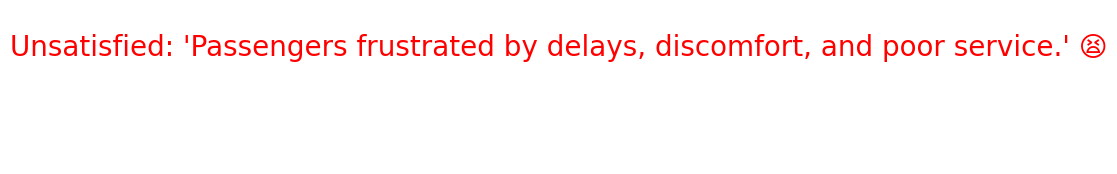

In [140]:
import emoji

# Dissatisfied(0) and Satisfied(1)

Predict=model_rf.predict([pre]) 
print("Predicted value:- ",Predict)
if Predict==1:
    plt.figure(figsize=(3,2))
    plt.text(1.0, 0.7,emoji.emojize("Satisfied: 'Passengers satisfied with service, comfort, and punctuality.' :grinning_face:"),  fontsize=20, ha='center', color='green')
    plt.axis('off')
    plt.show()
    
else:
    plt.figure(figsize=(3,2))
    plt.text(1.0, 0.7, emoji.emojize("Unsatisfied: 'Passengers frustrated by delays, discomfort, and poor service.' :tired_face:"), fontsize=20, ha='center', color='red')
    plt.axis('off')
    plt.show()

###### 